# 📊 Stochastic Oscillator Technical Indicator Project

## 🔹 Overview
This project demonstrates how to calculate and visualize the **Stochastic Oscillator**,  
a momentum indicator that compares a security’s closing price to its high–low range over a given period.

The Stochastic Oscillator consists of two lines:
- **%K (fast line):** Current close relative to the recent high–low range.  
- **%D (signal line):** Moving average of %K, typically 3 periods.

Values range from **0 to 100**:
- Above 80 → Overbought zone (potential reversal down).  
- Below 20 → Oversold zone (potential reversal up).  

---

## 🔹 Technical Background

### Formula
1. %K (raw stochastic):
\[
\%K_t = \frac{C_t - L_n}{H_n - L_n} \times 100
\]

2. %D (signal line):
\[
\%D_t = SMA_m(\%K_t)
\]

Where:
- \( C_t \) = current closing price  
- \( L_n \) = lowest low over last *n* periods  
- \( H_n \) = highest high over last *n* periods  
- \( n = 14 \) (default lookback for %K)  
- \( m = 3 \) (default smoothing for %D)  

In [1]:
print("Hello World!")

Hello World!


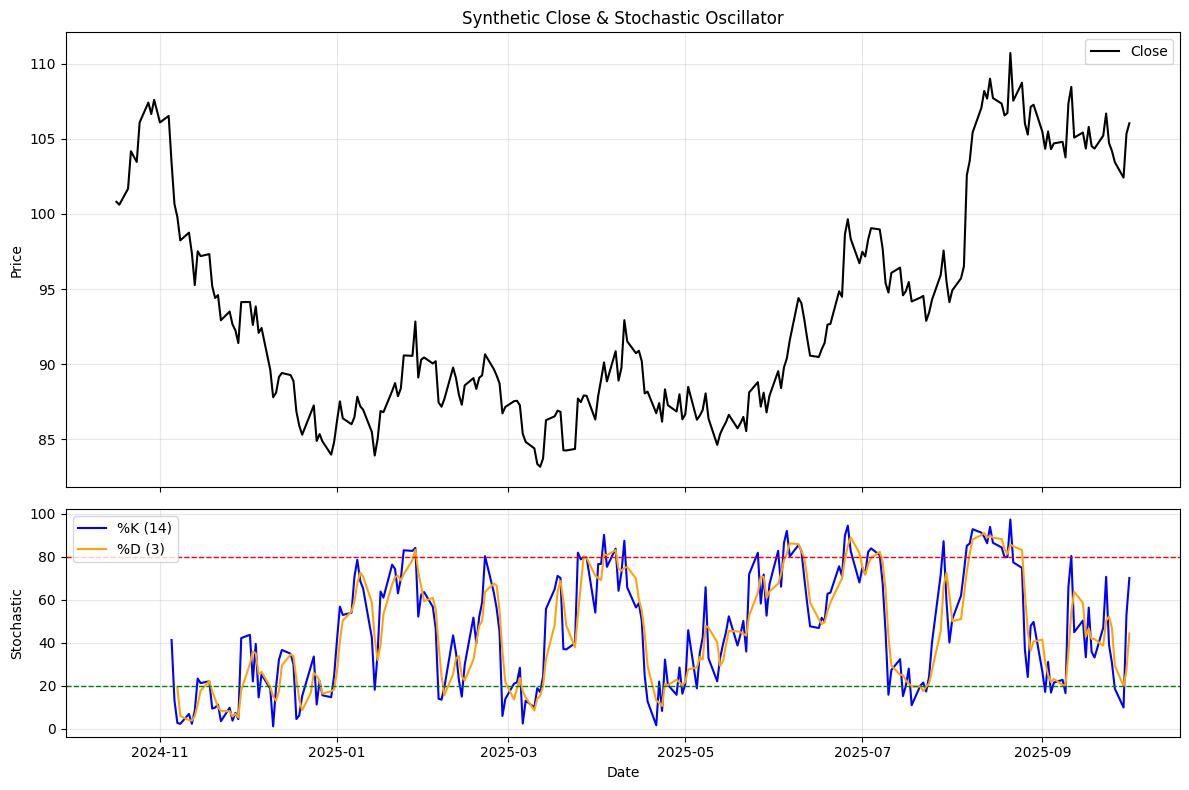

Mode: Synthetic
Rows: 250
Last Close: 106.04
Last %K(14): 70.09 | %D(3): 44.32


In [2]:
# ==== Stochastic Oscillator Project ====
# Works with synthetic data by default. Set RUN_MODE="yfinance" for real prices.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- Config --------
RUN_MODE   = "synthetic"   # "synthetic" or "yfinance"
TICKER     = "AAPL"        # used only if RUN_MODE="yfinance"
PERIOD     = "1y"
INTERVAL   = "1d"

K_LEN = 14   # lookback for %K
D_LEN = 3    # smoothing for %D
# -------------------------

# 1) Load Data
if RUN_MODE == "yfinance":
    try:
        import yfinance as yf
        df = yf.download(TICKER, period=PERIOD, interval=INTERVAL, auto_adjust=True, progress=False)
        if df is None or df.empty:
            raise RuntimeError("No data returned.")
        high = df["High"]
        low  = df["Low"]
        close= df["Close"]
        title = f"{TICKER} Close & Stochastic Oscillator"
    except Exception as e:
        print("Falling back to synthetic data because:", e)
        RUN_MODE = "synthetic"

if RUN_MODE == "synthetic":
    np.random.seed(42)
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=250)
    mu, sigma, dt = 0.10, 0.25, 1/252
    z = np.random.normal(size=len(dates))
    log_ret = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z
    price = 100*np.exp(np.cumsum(log_ret))
    close = pd.Series(price, index=dates, name="Close")
    # simulate high/low around close
    high = close + np.random.uniform(0,2,size=len(close))
    low  = close - np.random.uniform(0,2,size=len(close))
    title = "Synthetic Close & Stochastic Oscillator"

# 2) Compute Stochastic %K and %D
lowest_low  = low.rolling(K_LEN).min()
highest_high= high.rolling(K_LEN).max()
percent_k = 100 * (close - lowest_low) / (highest_high - lowest_low)
percent_d = percent_k.rolling(D_LEN).mean()

# 3) Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True,
                               gridspec_kw={'height_ratios':[2,1]})

# Price chart
ax1.plot(close.index, close, label="Close", color="black")
ax1.set_title(title)
ax1.set_ylabel("Price")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Stochastic chart
ax2.plot(percent_k.index, percent_k, label=f"%K ({K_LEN})", color="blue")
ax2.plot(percent_d.index, percent_d, label=f"%D ({D_LEN})", color="orange")
ax2.axhline(80, color="red", linestyle="--", linewidth=1)
ax2.axhline(20, color="green", linestyle="--", linewidth=1)
ax2.set_ylabel("Stochastic")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# 4) Summary
print("Mode:", "Real (yfinance)" if RUN_MODE=="yfinance" else "Synthetic")
print("Rows:", len(close))
print("Last Close:", round(close.iloc[-1],2))
print(f"Last %K({K_LEN}): {round(percent_k.iloc[-1],2)} | %D({D_LEN}): {round(percent_d.iloc[-1],2)}")
